# Import Library

In [ ]:
#5221811028_Hasna Oktaviani
#Prodi Sains Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import RobustScaler

# Load Dataset

In [ ]:
Koperasi = pd.read_csv('/content/Data_gabungan_Kreasi Multi.csv')

In [ ]:
Koperasi.head()

,No,nm_nas,tgl_buka,tenor,tgl_jt_tempo,kol,hari_tunggakan,pyd,angsuran,osl,...,tung_pokok,tung_sm,tung_denda,t_kewajiban,kol_in,sub_produk,keterangan,outlet_channel,status_kredit,ket_kredit
0,1,A*I T****H,2025-02-10 00:00:00.000000,12,2026-02-10 00:00:00.000000,1,0,10000000,983400,10000000,...,0,0,0,0,-,KREASI MULTI GUNA,-,-,KREDIT AKTIF,AKTIF
1,2,N*R F****A R*******I,2025-02-14 00:00:00.000000,24,2027-02-14 00:00:00.000000,1,0,15000000,812500,14375000,...,0,0,0,0,-,KREASI MULTI GUNA,-,-,KREDIT AKTIF,AKTIF
2,3,A****DI I****N,2025-02-21 00:00:00.000000,18,2026-08-21 00:00:00.000000,1,0,8000000,564500,8000000,...,0,0,0,0,-,KREASI MULTI GUNA,-,-,KREDIT AKTIF,AKTIF
3,4,M*H T****Q,2025-02-11 00:00:00.000000,36,2028-02-11 00:00:00.000000,1,0,30000000,1208400,30000000,...,0,0,0,0,-,KREASI MULTI GUNA,-,-,KREDIT AKTIF,AKTIF
4,5,D**N A********H,2024-12-28 00:00:00.000000,36,2027-12-28 00:00:00.000000,1,0,60000000,2356700,56666600,...,0,0,0,0,-,KREASI MULTI GUNA,REPEAT,-,KREDIT AKTIF,AKTIF


# EDA

In [ ]:
Koperasi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   No              200 non-null    int64  
 1   nm_nas          200 non-null    object 
 2   tgl_buka        200 non-null    object 
 3   tenor           200 non-null    int64  
 4   tgl_jt_tempo    200 non-null    object 
 5   kol             200 non-null    int64  
 6   hari_tunggakan  200 non-null    int64  
 7   pyd             200 non-null    int64  
 8   angsuran        200 non-null    int64  
 9   osl             200 non-null    int64  
 10  saldo_rek_tip   165 non-null    float64
 11  sisa_pokok      200 non-null    int64  
 12  tung_pokok      200 non-null    int64  
 13  tung_sm         200 non-null    int64  
 14  tung_denda      200 non-null    int64  
 15  t_kewajiban     200 non-null    int64  
 16  kol_in          45 non-null     object 
 17  sub_produk      45 non-null     obj

In [ ]:
Koperasi.describe()

,No,tenor,kol,hari_tunggakan,pyd,angsuran,osl,saldo_rek_tip,sisa_pokok,tung_pokok,tung_sm,tung_denda,t_kewajiban
count,200.000000,200.000000,200.00000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,1.650000e+02,2.000000e+02,2.000000e+02,2.000000e+02,200.000000,2.000000e+02
mean,44.625000,25.605000,1.22000,5.620000,4.563850e+07,2.319628e+06,3.286216e+07,6.213007e+04,3.222728e+07,6.348771e+05,1.979789e+05,14834.055000,8.476901e+05
std,34.088775,10.818232,0.43882,16.788235,4.446748e+07,2.105741e+06,4.075901e+07,2.876486e+05,4.005556e+07,1.917532e+06,6.248631e+05,57849.092291,2.582412e+06
min,1.000000,3.000000,1.00000,0.000000,3.000000e+06,2.875000e+05,8.880000e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
25%,17.000000,18.000000,1.00000,0.000000,1.962500e+07,1.149500e+06,1.000000e+07,0.000000e+00,1.000000e+07,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
50%,34.000000,24.000000,1.00000,0.000000,3.500000e+07,1.906300e+06,2.333300e+07,2.200000e+02,2.333280e+07,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
75%,70.250000,36.000000,1.00000,0.000000,6.000000e+07,2.702300e+06,4.041640e+07,1.714000e+03,3.999970e+07,0.000000e+00,0.000000e+00,0.000000,0.000000e+00
max,120.000000,60.000000,3.00000,113.000000,3.500000e+08,1.520000e+07,3.402777e+08,2.383400e+06,3.305554e+08,1.833360e+07,6.138000e+06,602688.000000,2.507429e+07


In [ ]:
# Cek missing values
Koperasi.isnull().sum()

No                  0
nm_nas              0
tgl_buka            0
tenor               0
tgl_jt_tempo        0
kol                 0
hari_tunggakan      0
pyd                 0
angsuran            0
osl                 0
saldo_rek_tip      35
sisa_pokok          0
tung_pokok          0
tung_sm             0
tung_denda          0
t_kewajiban         0
kol_in            155
sub_produk        155
keterangan        137
outlet_channel    155
status_kredit       0
ket_kredit          0
dtype: int64

# Preprocessing

In [ ]:
print(Koperasi[['tgl_buka', 'tgl_jt_tempo']].head())

                     tgl_buka                tgl_jt_tempo
0  2025-02-10 00:00:00.000000  2026-02-10 00:00:00.000000
1  2025-02-14 00:00:00.000000  2027-02-14 00:00:00.000000
2  2025-02-21 00:00:00.000000  2026-08-21 00:00:00.000000
3  2025-02-11 00:00:00.000000  2028-02-11 00:00:00.000000
4  2024-12-28 00:00:00.000000  2027-12-28 00:00:00.000000


In [ ]:
# Ubah tanggal
Koperasi['tgl_buka'] = pd.to_datetime(Koperasi['tgl_buka'], errors='coerce')
Koperasi['tgl_jt_tempo'] = pd.to_datetime(Koperasi['tgl_jt_tempo'], errors='coerce')

In [ ]:
# Hitung lama pinjaman dan usia pinjaman
Koperasi['lama_pinjam'] = (Koperasi['tgl_jt_tempo'] - Koperasi['tgl_buka']).dt.days
Koperasi['usia_pinjaman_bulan'] = ((pd.Timestamp.today() - Koperasi['tgl_buka']).dt.days // 30).fillna(0).astype(int)

In [ ]:
# Isi missing value pada variabel saldo
Koperasi['saldo_rek_tip'] = Koperasi['saldo_rek_tip'].fillna(Koperasi['saldo_rek_tip'].median())

In [ ]:
Koperasi.head()

,No,nm_nas,tgl_buka,tenor,tgl_jt_tempo,kol,hari_tunggakan,pyd,angsuran,osl,...,tung_denda,t_kewajiban,kol_in,sub_produk,keterangan,outlet_channel,status_kredit,ket_kredit,lama_pinjam,usia_pinjaman_bulan
0,1,A*I T****H,2025-02-10,12,2026-02-10,1,0,10000000,983400,10000000,...,0,0,-,KREASI MULTI GUNA,-,-,KREDIT AKTIF,AKTIF,365,4
1,2,N*R F****A R*******I,2025-02-14,24,2027-02-14,1,0,15000000,812500,14375000,...,0,0,-,KREASI MULTI GUNA,-,-,KREDIT AKTIF,AKTIF,730,3
2,3,A****DI I****N,2025-02-21,18,2026-08-21,1,0,8000000,564500,8000000,...,0,0,-,KREASI MULTI GUNA,-,-,KREDIT AKTIF,AKTIF,546,3
3,4,M*H T****Q,2025-02-11,36,2028-02-11,1,0,30000000,1208400,30000000,...,0,0,-,KREASI MULTI GUNA,-,-,KREDIT AKTIF,AKTIF,1095,4
4,5,D**N A********H,2024-12-28,36,2027-12-28,1,0,60000000,2356700,56666600,...,0,0,-,KREASI MULTI GUNA,REPEAT,-,KREDIT AKTIF,AKTIF,1095,5


In [ ]:
print(Koperasi[['tgl_buka', 'tgl_jt_tempo', 'lama_pinjam', 'usia_pinjaman_bulan']].head())

    tgl_buka tgl_jt_tempo  lama_pinjam  usia_pinjaman_bulan
0 2025-02-10   2026-02-10          365                    4
1 2025-02-14   2027-02-14          730                    3
2 2025-02-21   2026-08-21          546                    3
3 2025-02-11   2028-02-11         1095                    4
4 2024-12-28   2027-12-28         1095                    5


In [ ]:
print(Koperasi['saldo_rek_tip'].isna().sum())  # Jumlah data yang masih NaN

0


# Feature Engineering

In [ ]:
df = Koperasi.copy()

df['persentase_tunggakan'] = (df['tung_pokok'] + df['tung_denda']) / (df['saldo_rek_tip'] + 1)
df['rasio_usia_vs_lama_pinjam'] = df['usia_pinjaman_bulan'] / (df['lama_pinjam'] + 1)
df['log_saldo'] = np.log1p(df['saldo_rek_tip'])
df['status_pinjaman_lama'] = (df['lama_pinjam'] > 365).astype(int)

def kategori_denda(denda):
    if denda < 100_000:
        return 'kecil'
    elif denda < 1_000_000:
        return 'sedang'
    else:
        return 'besar'

df['kategori_denda'] = df['tung_denda'].apply(kategori_denda)

# Buat dummy variabel agar semua kategori ada
kategori_columns = ['kategori_denda_sedang', 'kategori_denda_besar']
dummies = pd.get_dummies(df['kategori_denda'], prefix='kategori_denda')
dummies = dummies.reindex(columns=kategori_columns, fill_value=0)

# Gabungkan kembali
df = pd.concat([df, dummies], axis=1)

# Fitur akhir
final_features = [
    'hari_tunggakan', 'tung_pokok', 'tung_denda', 'lama_pinjam', 'usia_pinjaman_bulan', 'saldo_rek_tip',
    'persentase_tunggakan', 'rasio_usia_vs_lama_pinjam', 'log_saldo', 'status_pinjaman_lama',
    'kategori_denda_sedang', 'kategori_denda_besar'
]


In [ ]:
print(df[['hari_tunggakan', 'tung_pokok', 'tung_denda', 'lama_pinjam', 'usia_pinjaman_bulan', 'saldo_rek_tip',
    'persentase_tunggakan', 'rasio_usia_vs_lama_pinjam', 'log_saldo', 'status_pinjaman_lama',
    'kategori_denda_sedang', 'kategori_denda_besar']].head())

   hari_tunggakan  tung_pokok  tung_denda  lama_pinjam  usia_pinjaman_bulan  \
0               0           0           0          365                    4   
1               0           0           0          730                    4   
2               0           0           0          546                    3   
3               0           0           0         1095                    4   
4               0           0           0         1095                    5   

   saldo_rek_tip  persentase_tunggakan  rasio_usia_vs_lama_pinjam  log_saldo  \
0            0.0                   0.0                   0.010929   0.000000   
1            0.0                   0.0                   0.005472   0.000000   
2       565000.0                   0.0                   0.005484  13.244583   
3       900000.0                   0.0                   0.003650  13.710151   
4            0.0                   0.0                   0.004562   0.000000   

   status_pinjaman_lama  kategori_denda_seda

# Membuat Model

# Standarisasi

In [ ]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[final_features])

Metode Elbow

In [ ]:
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

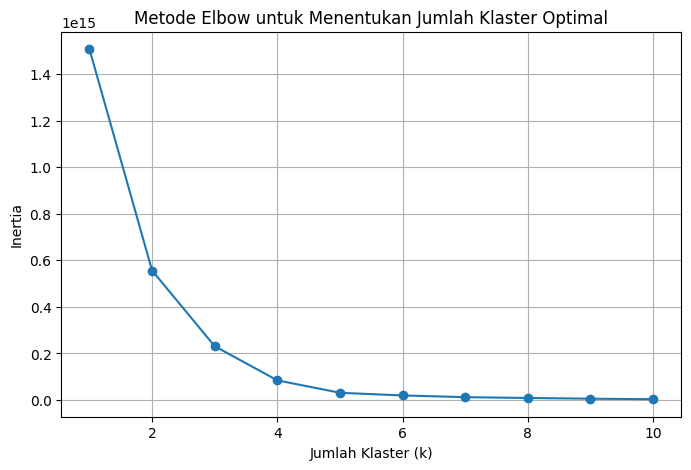

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker='o')
plt.title('Metode Elbow untuk Menentukan Jumlah Klaster Optimal')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

Clustering menggunakan k-means dengan N=3 berdasarkan Elbow

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

Menggunakan PCA

In [ ]:
pca_full = PCA(n_components=0.95)
X_pca_reduced = pca_full.fit_transform(X_scaled)

# Evaluasi

In [ ]:
# Evaluasi clustering
print("Silhouette Score:", silhouette_score(X_pca_reduced, df['cluster']))

Silhouette Score: 0.866403644541618


Membuat label risiko

In [ ]:
cluster_risk_metric = df.groupby('cluster')[['hari_tunggakan', 'tung_pokok', 'tung_denda']].mean()
# menambahkan bobot jika relevan:
cluster_score = (cluster_risk_metric['hari_tunggakan'] * 0.5 +
                 cluster_risk_metric['tung_pokok'] * 0.3 +
                 cluster_risk_metric['tung_denda'] * 0.2)

# Urutan risiko
risk_order = cluster_score.sort_values().index
risk_labels = {cluster: label for cluster, label in zip(risk_order, ['Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi'])}
df['risk_label'] = df['cluster'].map(risk_labels)

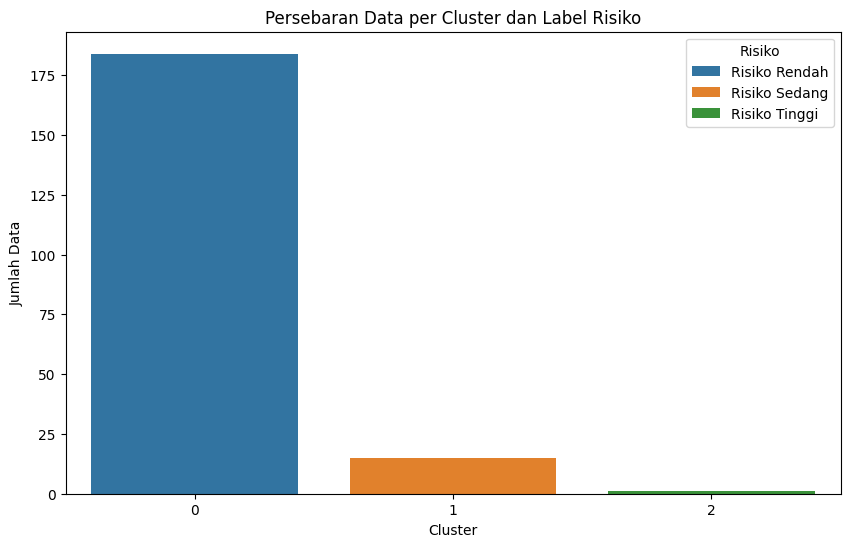

In [ ]:
# Grfaik persebaran data per cluster dan label risiko
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cluster', hue='risk_label')
plt.title("Persebaran Data per Cluster dan Label Risiko")
plt.xlabel("Cluster")
plt.ylabel("Jumlah Data")
plt.legend(title="Risiko")
plt.show()
